# Libraries

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

# Load Data

In [2]:
df = pd.read_excel("./data/TGF N-prod data.xlsx", sheet_name = 0, header = 1)
df = df.loc[2:].reset_index(drop = True)
df.rename(columns={"Variable": "Batch Full Name", "CAMPAIGN": "Batch"}, inplace=True)
df.head()

,Batch Full Name,Batch,STR2K_D05_2_1_PA_HPLC_Concentration,STR2K_D06_2_1_PA_HPLC_Concentration,STR2K_D07_2_1_PA_HPLC_Concentration,STR2K_D09_2_1_PA_HPLC_Concentration,STR2K_D10_2_1_PA_HPLC_Concentration,STR2K_D11_2_1_PA_HPLC_Concentration,STR2K_D12_2_1_PA_HPLC_Concentration,STR2K_D13_2_1_PA_HPLC_Concentration,...,temperature switch process time_1,1M Sodium Carbonate Solution,COPPER SULFATE 50MM,Cell Boost 7a feed medium,Cell Boost 7b feed medium,Glucose 500 g/L,OPTICHO GROWTH MEDIUM,STR2K_D14_2_Bioburden_TAMC,STR2K_D14_2_Bioburden_TAMC + TYMC,STR2K_D14_2_Bioburden_TYMC
0,GA001_TGFBxPD1 N STR2000L_1003472,GA001,0.22,0.35,0.54,1.25,1.69,2.27,2.65,3.13,...,NaN,1003086,1003508,1003442,1003443,1003434,1003435,<1,<1,<1
1,GA002_TGFBxPD1 N STR2000L_1003601,GA002,0.21,0.33,0.51,1.16,1.56,2.06,2.54,3.16,...,NaN,1003086,1003623,1003560,1003561,1003434,1003510,<1,<1,<1
2,GA003_TGFBxPD1 N STR2000L_1005331,GA003,0.2,0.32,0.53,1.31,1.76,2.3,1.66,3.14,...,116,1004762,1005428,1005295,1005424,1004750,1005159,<1,<1,<1
3,GA004_TGFBxPD1 N STR2000L_1005425,GA004,NaN,0.32,0.53,1.2,1.6,2.18,2.72,3.17,...,114,1004762,1005429,1005295,1005424,1004750,1005160,<1,<1,<1
4,GA005_TGFBxPD1 N STR2000L_1005446,GA005,0.21,0.34,0.54,1.26,1.7,2.28,2.81,3.29,...,118,1004762,1005536,1005328,1005424,1004750,1005273,<1,<1,<1


# Split Relevant Data

In [3]:
medium_df = df[["Batch", "Batch Full Name"] + df.columns[-9:-3].tolist()]
labels_df = df[["Batch", "Batch Full Name"] + df.columns[2:11].tolist()]
feats_df  = df[["Batch", "Batch Full Name"] + df.columns[11:-9].tolist()]

medium_cols = df.columns[-9:-3].tolist()
medium_df[medium_cols] = medium_df[medium_cols].astype(float)

# Modeling

In [4]:
X = feats_df.drop(columns=["Batch", "Batch Full Name"]).astype(float)
y = labels_df[labels_df.columns[2]]

numeric_cols = X.select_dtypes(include='number').columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].mean())

y = y.fillna(y.mean())

In [5]:
model = XGBRegressor()
model.fit(X, y)

imp_df = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_})
imp_df = imp_df.sort_values(by = "Importance", ascending = False).reset_index(drop = True)
imp_df["Feature"] = imp_df["Feature"].apply(lambda x: x.split(".")[-1])
imp_df.head(5)

,Feature,Importance
0,inoculum weight_1,0.839328
1,final bioreactor weight_1,0.077797
2,base total quantity_1,0.052989
3,cell concentration at end_1,0.018332
4,process step duration_1,0.011554


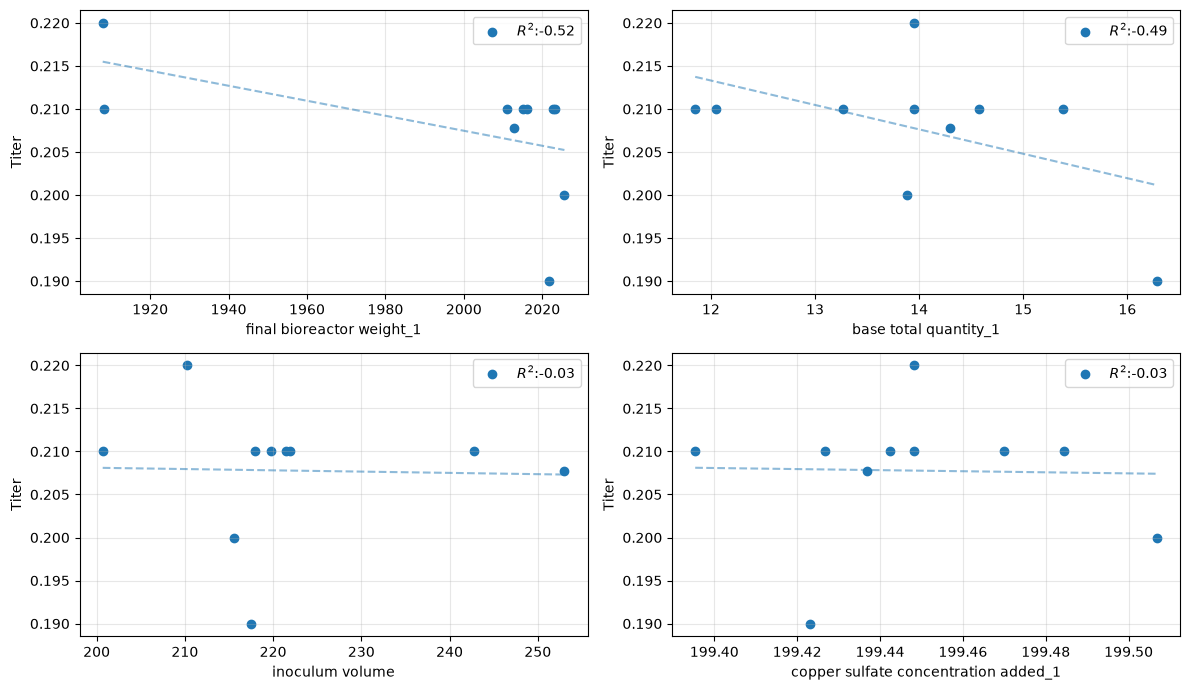

In [6]:
fig, axs = plt.subplots(2, 2, figsize = (12, 7))
feats = [
    "final bioreactor weight_1", 
    "base total quantity_1",
    "inoculum volume",
    "copper sulfate concentration added_1"
]

for i, feat in enumerate(feats):
    row_idx = i // 2
    col_idx = i % 2

    ax = axs[row_idx, col_idx]

    output = linregress(X[feat].tolist(), y.tolist())

    x_s = [X[feat].min(), X[feat].max()]
    y_s = [(output.slope * a) + output.intercept for a in x_s]

    ax.scatter(X[feat], y, label = f"$R^2$:{output.rvalue:.2f}")
    ax.plot(x_s, y_s, linestyle = '--', alpha = 0.5)
    ax.set_xlabel(feat.split(".")[-1])
    ax.set_ylabel("Titer")
    ax.grid(alpha = 0.3)
    ax.legend()
fig.tight_layout()

# Day-wise Feature Importance

Does the importance of each feature in `feats_df` change depending on which day's titer in `labels_df` we predict?

**Four plot types, each answering a different question:**

| Figure | Form | Question it answers |
|---|---|---|
| 1 | **Heatmap** (features × days) | Which features matter, and how much, on every day at once? — the overview |
| 2 | **Bump chart** (rank vs. day) | Does the *ordering* reshuffle? — the "it varies by day" claim itself |
| 3 | **Signed correlation heatmap** (diverging) | Which *direction* does each effect point, and does the sign flip between days? |
| 4 | **Stability small multiples** | Is the day-to-day movement bigger than what pure noise produces? |

A fifth check follows figure 4: it compares the real ranking with the ranking the same model produces from a *shuffled* titer.

**Read figure 4 and check 5 first.** With **10 batches and 17 features** a single `XGBRegressor().fit()` can place a split almost
anywhere, so raw `feature_importances_` are dominated by sampling noise. Two mitigations are applied throughout:

- importance is **bagged** — averaged over 200 bootstrap resamples of the batches, with shallow trees (`max_depth=2`) — instead of read off one fit;
- a **null baseline** is computed by shuffling the titer values and re-fitting, so we can see how much apparent importance arises from nothing at all.

Batches with a missing titer on a given day are dropped for that day rather than mean-filled (with n=10 one filled row is 10% of the data,
and it would pull importance toward whatever feature best predicts the mean).


In [7]:
import re
import matplotlib as mpl
from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap

# --- plot tokens: one sequential ramp for magnitude, one diverging pair for polarity,
# --- three categorical hues (validated colourblind-safe on all pairs) for emphasis
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]
DEEMPH = "#d8d7d0"
SEQ = LinearSegmentedColormap.from_list("seq_blue", [
    "#f4f8fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div_blue_red", [
    "#0d366b", "#256abf", "#86b6ef", "#cde2fb", "#f0efec", "#f6cac9", "#ee9c9b", "#e34948", "#a32c2b"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 11, "legend.frameon": False,
})


In [8]:
# --- one importance value per (feature, day). Takes ~45 s; lower N_REP to speed up.
X_all = feats_df.drop(columns=["Batch", "Batch Full Name"]).astype(float)
X_all = X_all.loc[:, X_all.nunique(dropna=True) > 1]          # drop constant columns
day_cols = labels_df.columns[2:].tolist()
days = [int(re.search(r"_D(\d+)_", c).group(1)) for c in day_cols]

N_REP, RNG = 200, np.random.default_rng(0)


def _xgb():
    # shallow + few trees: with n=10 batches a default XGBRegressor memorises the rows
    return XGBRegressor(n_estimators=40, max_depth=2, learning_rate=0.1,
                        reg_lambda=1.0, verbosity=0)


def bagged_importance(X, y, n_rep=N_REP, permute=False):
    """Gain importance over bootstrap resamples of the batches, or over label permutations."""
    n, out = len(y), np.empty((n_rep, X.shape[1]))
    for r in range(n_rep):
        if permute:
            idx, yy = np.arange(n), RNG.permutation(y.to_numpy())
        else:
            idx = RNG.integers(0, n, n)
            yy = y.to_numpy()[idx]
        out[r] = _xgb().fit(X.to_numpy()[idx], yy).feature_importances_
    return out


imp, imp_lo, imp_hi, null_hi, null_mu, rho = ({} for _ in range(6))
for col, d in zip(day_cols, days):
    y = pd.to_numeric(labels_df[col], errors="coerce")
    keep = y.notna()                                  # drop batches with no titer that day
    Xd, yd = X_all[keep], y[keep]
    boot = bagged_importance(Xd, yd)
    # imp is the MEAN of the resampled answers — this is the number every figure below plots.
    # imp_lo/imp_hi are percentiles of the same answers, so imp need not sit midway between them
    # (these importance distributions are lopsided: many small values, a few large ones).
    imp[d] = pd.Series(boot.mean(0), index=X_all.columns)
    imp_lo[d] = pd.Series(np.percentile(boot, 25, axis=0), index=X_all.columns)
    imp_hi[d] = pd.Series(np.percentile(boot, 75, axis=0), index=X_all.columns)
    nul = bagged_importance(Xd, yd, permute=True)      # identical fits, titer shuffled
    null_hi[d] = pd.Series(np.percentile(nul, 95, axis=0), index=X_all.columns)   # noise floor
    null_mu[d] = pd.Series(nul.mean(0), index=X_all.columns)                      # noise ranking
    rho[d] = pd.Series([spearmanr(Xd[c], yd, nan_policy="omit").statistic for c in X_all.columns],
                       index=X_all.columns)

imp, imp_lo, imp_hi = pd.DataFrame(imp), pd.DataFrame(imp_lo), pd.DataFrame(imp_hi)
null_hi, null_mu, rho = pd.DataFrame(null_hi), pd.DataFrame(null_mu), pd.DataFrame(rho)

order = imp.mean(axis=1).sort_values(ascending=False).index   # rows sorted by mean importance
imp, imp_lo, imp_hi, null_hi, null_mu, rho = (
    m.loc[order] for m in (imp, imp_lo, imp_hi, null_hi, null_mu, rho))
ranks = imp.rank(ascending=False, axis=0)
xt = [f"D{d:02d}" for d in days]


def _annotate(ax, M, fmt, cmap, vmax, vmin=0.0):
    """Print every cell value, so the heatmap is readable without relying on colour alone."""
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.iat[i, j]
            if pd.isna(v):
                continue
            lum = np.dot(cmap((v - vmin) / (vmax - vmin))[:3], [0.299, 0.587, 0.114])
            ax.text(j, i, format(v, fmt).replace("0.", ".").replace("-.", "–."),
                    ha="center", va="center", fontsize=6.5,
                    color=SURFACE if lum < 0.55 else INK2)


def _cells(ax, labels):
    ax.set_xticks(range(len(days)), xt)
    ax.set_yticks(range(len(labels)), [c.replace("_1", "") for c in labels], fontsize=8)
    ax.set_xticks(np.arange(len(days) + 1) - .5, minor=True)
    ax.set_yticks(np.arange(len(labels) + 1) - .5, minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=2)   # 2px surface gap between cells
    ax.grid(False, which="major")
    ax.tick_params(which="both", length=0)
    ax.set_xlabel("Harvest day of titer measurement")


def _bar(fig, ax, im, label):
    cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.035)
    cb.set_label(label, color=INK2, fontsize=8)
    cb.outline.set_visible(False)
    cb.ax.tick_params(length=0, colors=MUTED)


imp.round(3)


,5,6,7,9,10,11,12,13,14
cell concentration at end_1,0.215,0.064,0.260,0.321,0.333,0.155,0.589,0.241,0.322
base total quantity_1,0.323,0.207,0.283,0.249,0.216,0.163,0.119,0.257,0.272
cell concentration at start_1,0.032,0.394,0.136,0.025,0.019,0.038,0.008,0.138,0.053
inoculum volume,0.023,0.116,0.050,0.065,0.068,0.140,0.020,0.032,0.083
bioreactor cooling duration,0.000,0.020,0.060,0.095,0.091,0.052,0.022,0.185,0.032
final bioreactor weight_1,0.143,0.093,0.020,0.039,0.046,0.079,0.019,0.030,0.068
copper sulfate concentration added_1,0.000,0.007,0.163,0.045,0.018,0.058,0.107,0.068,0.026
igg concentration at end_1,0.143,0.048,0.000,0.014,0.010,0.064,0.037,0.002,0.132
copper sulfate quantity_1,0.000,0.000,0.019,0.125,0.157,0.067,0.004,0.032,0.013
medium addition_1,0.000,0.017,0.000,0.016,0.032,0.090,0.027,0.000,0.000


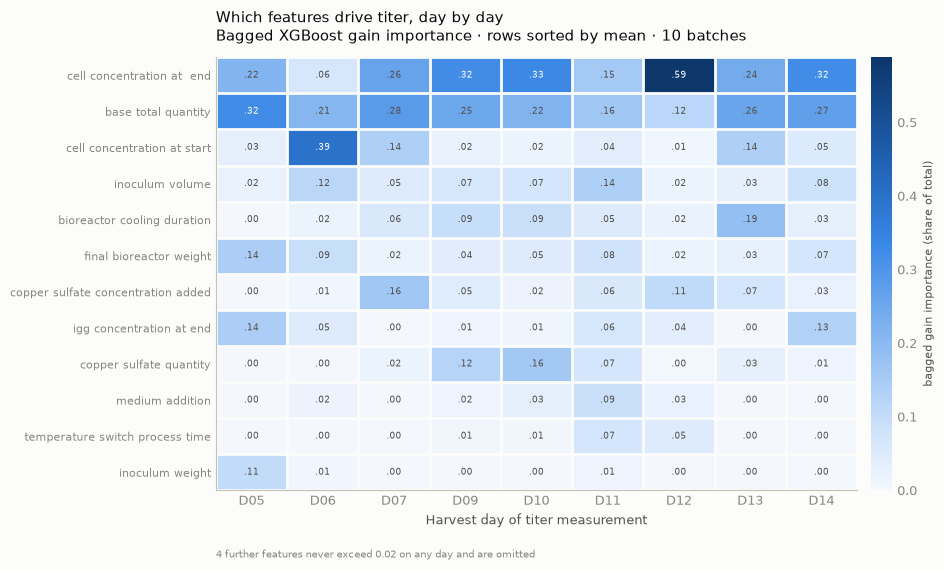

In [9]:
# --- FIG 1: heatmap — the overview. Magnitude in a grid, so one sequential hue, light -> dark.
shown = [f for f in order if imp.loc[f].max() >= 0.02]        # fold the never-used tail
hidden = len(order) - len(shown)
M = imp.loc[shown]
vmax = float(M.max().max())

fig, ax = plt.subplots(figsize=(9.5, 5.8))
im = ax.imshow(M.to_numpy(), cmap=SEQ, vmin=0, vmax=vmax, aspect="auto")
_cells(ax, shown)
_annotate(ax, M, ".2f", SEQ, vmax)
_bar(fig, ax, im, "bagged gain importance (share of total)")
ax.set_title("Which features drive titer, day by day\n"
             f"Bagged XGBoost gain importance · rows sorted by mean · {X_all.shape[0]} batches",
             loc="left", pad=12)
if hidden:
    ax.annotate(f"{hidden} further features never exceed 0.02 on any day and are omitted",
                xy=(0, -0.155), xycoords="axes fraction", fontsize=7.5, color=MUTED)
fig.tight_layout()
plt.show()


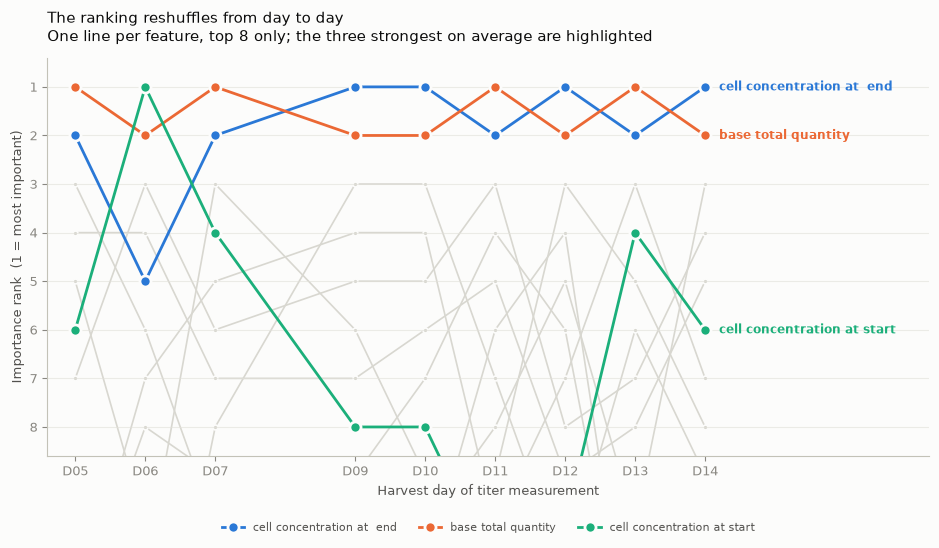

In [10]:
# --- FIG 2: bump chart — the reshuffling itself. Emphasis form: 3 hues + gray context.
top3 = list(order[:3])
CTX = 8                                    # gray context lines: features reaching top-8 once
ctx = [f for f in order if f not in top3 and ranks.loc[f].min() <= CTX]

fig, ax = plt.subplots(figsize=(9.5, 5.6))
for f in ctx:
    ax.plot(days, ranks.loc[f], color=DEEMPH, lw=1.2, marker="o", ms=3.5,
            mfc=DEEMPH, mec=SURFACE, mew=1.2, zorder=1)
for k, f in enumerate(top3):
    ax.plot(days, ranks.loc[f], color=SERIES[k], lw=2, marker="o", ms=8,
            mfc=SERIES[k], mec=SURFACE, mew=2, zorder=3, label=f.replace("_1", ""))
    ax.annotate(f.replace("_1", ""), (days[-1], ranks.loc[f].iloc[-1]),   # direct label
                textcoords="offset points", xytext=(10, 0), va="center",
                fontsize=8.5, color=SERIES[k], fontweight="bold")
ax.invert_yaxis()
ax.set_ylim(CTX + 0.6, 0.4)
ax.set_yticks(range(1, CTX + 1))
ax.set_ylabel("Importance rank  (1 = most important)")
ax.set_xlabel("Harvest day of titer measurement")
ax.set_xticks(days, xt)
ax.set_xlim(days[0] - 0.4, days[-1] + 3.2)
ax.grid(axis="y", alpha=0.6)
ax.set_title("The ranking reshuffles from day to day\n"
             f"One line per feature, top {CTX} only; the three strongest on average are highlighted",
             loc="left", pad=12)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncols=3, fontsize=8, labelcolor=INK2)
fig.tight_layout()
plt.show()


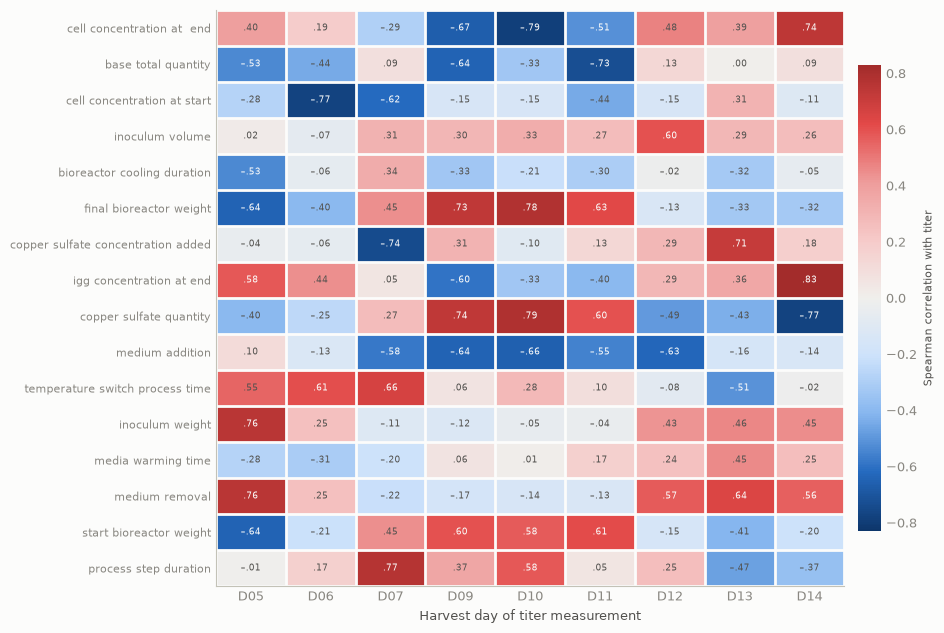

In [11]:
# --- FIG 3: signed heatmap — polarity, so a diverging pair with a neutral gray midpoint.
# Gain importance is unsigned and splits credit arbitrarily between correlated features;
# rank correlation has neither problem, so it is the better read on direction.
vm = float(np.nanmax(np.abs(rho.to_numpy())))

fig, ax = plt.subplots(figsize=(9.5, 6.4))
im = ax.imshow(rho.to_numpy(), cmap=DIV, vmin=-vm, vmax=vm, aspect="auto")
_cells(ax, order)
_annotate(ax, rho, ".2f", DIV, vm, -vm)
_bar(fig, ax, im, "Spearman correlation with titer")
# ax.set_title("Direction of each effect, day by day\n"
#              "Spearman rank correlation · red = higher feature, higher titer · blue = inverse",
#              loc="left", pad=12)
fig.tight_layout()
plt.show()


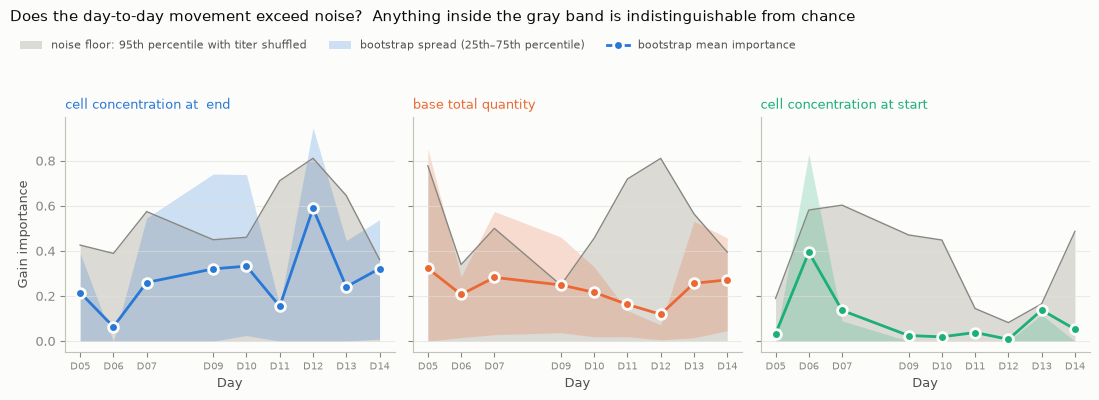

Rank agreement between consecutive days (Spearman of the importance vectors):
  D05 -> D06: +0.74
  D06 -> D07: +0.68
  D07 -> D09: +0.82
  D09 -> D10: +0.97
  D10 -> D11: +0.81
  D11 -> D12: +0.80
  D12 -> D13: +0.57
  D13 -> D14: +0.80
  mean +0.77

Per-feature summary across the 9 days:


,mean imp,best rank,worst rank,days above noise floor
cell concentration at end_1,0.278,1,5,0
base total quantity_1,0.232,1,2,1
cell concentration at start_1,0.094,1,11,0
inoculum volume,0.066,3,8,0
bioreactor cooling duration,0.062,3,12,0
final bioreactor weight_1,0.060,4,9,0
copper sulfate concentration added_1,0.055,3,12,0
igg concentration at end_1,0.050,3,10,0


In [12]:
# --- FIG 4: small multiples — the sanity check. Bagged mean vs. a shuffled-label null.
# The line is the MEAN of the 200 bootstrap answers (the same number figs 1-3 plot);
# the band is the 25th-75th percentile of those answers, so the line need not sit in its centre.
fig, axs = plt.subplots(1, 3, figsize=(11, 4.0), sharey=True)
for k, (f, ax) in enumerate(zip(top3, axs)):
    ax.fill_between(days, 0, null_hi.loc[f], color=DEEMPH, alpha=0.9, lw=0,
                    label="noise floor: 95th percentile with titer shuffled")
    ax.plot(days, null_hi.loc[f], color=MUTED, lw=1, zorder=2)
    ax.fill_between(days, imp_lo.loc[f], imp_hi.loc[f], color=SERIES[k], alpha=0.22, lw=0,
                    label="bootstrap spread (25th–75th percentile)")
    ax.plot(days, imp.loc[f], color=SERIES[k], lw=2, marker="o", ms=7,
            mfc=SERIES[k], mec=SURFACE, mew=2, zorder=3, label="bootstrap mean importance")
    ax.set_title(f.replace("_1", ""), loc="left", fontsize=9.5, color=SERIES[k])
    ax.set_xticks(days, xt, fontsize=7.5)
    ax.grid(axis="y", alpha=0.6)
    ax.set_xlabel("Day")
    if k == 0:
        ax.set_ylabel("Gain importance")
        h, l = ax.get_legend_handles_labels()
fig.suptitle("Does the day-to-day movement exceed noise?  "
             "Anything inside the gray band is indistinguishable from chance",
             x=0.006, y=0.985, ha="left", fontsize=11, color=INK)
fig.legend(h, l, loc="upper left", bbox_to_anchor=(0.006, 0.935), ncols=3,
           fontsize=8, labelcolor=INK2)
fig.tight_layout(rect=(0, 0, 1, 0.87))
plt.show()

print("Rank agreement between consecutive days (Spearman of the importance vectors):")
cons = [spearmanr(imp[days[i]], imp[days[i + 1]]).statistic for i in range(len(days) - 1)]
for i, c in enumerate(cons):
    print(f"  D{days[i]:02d} -> D{days[i+1]:02d}: {c:+.2f}")
print(f"  mean {np.mean(cons):+.2f}\n")

summ = pd.DataFrame({"mean imp": imp.mean(axis=1), "best rank": ranks.min(axis=1).astype(int),
                     "worst rank": ranks.max(axis=1).astype(int),
                     "days above noise floor": (imp > null_hi).sum(axis=1)})
print(f"Per-feature summary across the {len(days)} days:")
summ.head(8).round(3)


### Check 5: is the *ranking* itself distinguishable from noise?

Figure 4 tests each feature's day-to-day movement against a shuffled-titer null. The stronger test is to throw the whole ranking
against that null: shuffle the titer, re-fit, and see whether the order that comes out still looks like the real one.


In [13]:
# --- Figure 4 asks "is the day-to-day movement bigger than noise?". This asks the sharper
# --- question: is the *ranking itself* bigger than noise? Compare the real ranking with the
# --- one the model produces when the titer is shuffled (null_mu, from the compute cell above).
real_rank, noise_rank = imp.mean(axis=1), null_mu.mean(axis=1)
print("Spearman(real ranking, ranking from shuffled titer) = "
      f"{spearmanr(real_rank, noise_rank).statistic:+.2f}    ({len(real_rank)} features)\n")
print(pd.DataFrame({"real": real_rank, "from shuffled titer": noise_rank,
                    "if all were equal": 1 / len(real_rank)}).head(6).round(3), "\n")

# --- Part of that ranking is not even a property of the columns' contents: gain importance
# --- breaks ties by column position, so merely re-ordering the features changes which ones
# --- the noise favours. Only a feature that stays on top under every ordering is worth
# --- trusting. (Exact values move between runs; the point is that the winners change.)
print("Top features under a shuffled titer, for three different orderings of the columns:")
for s in range(3):
    cols = X_all.columns.to_numpy()[np.random.default_rng(s).permutation(X_all.shape[1])]
    nm = np.zeros(X_all.shape[1])
    for col in day_cols:
        y = pd.to_numeric(labels_df[col], errors="coerce")
        keep = y.notna()
        nm += bagged_importance(X_all.loc[keep, cols], y[keep], n_rep=40, permute=True).mean(0)
    top = pd.Series(nm / len(day_cols), index=cols).nlargest(3)
    print(f"  ordering {s}:  "
          + "  ·  ".join(f"{k.replace('_1', '')} {v:.3f}" for k, v in top.items()))


Spearman(real ranking, ranking from shuffled titer) = +0.90    (16 features)

                                real  from shuffled titer  if all were equal
cell concentration at  end_1   0.278                0.128              0.062
base total quantity_1          0.232                0.136              0.062
cell concentration at start_1  0.094                0.063              0.062
inoculum volume                0.066                0.088              0.062
bioreactor cooling duration    0.062                0.090              0.062
final bioreactor weight_1      0.060                0.081              0.062 

Top features under a shuffled titer, for three different orderings of the columns:
  ordering 0:  cell concentration at  end 0.131  ·  base total quantity 0.127  ·  igg concentration at end 0.116
  ordering 1:  bioreactor cooling duration 0.129  ·  medium removal 0.126  ·  igg concentration at end 0.122
  ordering 2:  igg concentration at end 0.148  ·  base total quantity 0.122 

### Reading the figures

Every figure plots the **mean** of the 200 bootstrap answers. In figure 4 the band around that line is the 25th–75th percentile of the
same answers, so the line is not necessarily centred in its band — these importance distributions are lopsided (many small values, a few large).

**The day-to-day variation is an artefact of the estimator rather than a property of the process — and the ranking itself is barely
distinguishable from what the model produces out of nothing.** Four things point the same way:

1. **The ranking reproduces itself from pure noise.** Shuffle the titer, re-fit, and the resulting ranking still agrees with the real one at
   **Spearman ≈ +0.9** (check 5). With no signal at all the importance is nowhere near evenly spread: `base total quantity` collects ≈0.14 and
   `cell concentration at end` ≈0.13, against 0.06 if all 16 features shared it equally. So most of the ranking reports which columns are
   *structurally able to win a split*, not which ones predict titer.
2. **Part of it is not even about the columns' contents.** Gain importance breaks ties by column position, so simply re-ordering `feats_df`
   changes which features the noise favours — e.g. `medium removal`, whose real importance is 0.002, reaches the noise top three under one
   ordering. Only a feature that stays on top under *every* ordering is worth a second look.
3. **The bagged mean lies inside the shuffled-titer noise floor on almost every day** — in figure 4 the `days above noise floor` column is
   0 or 1 out of 9 for every single feature.
4. **The sign flips.** In figure 3 the leading feature's correlation with titer runs +0.40 → −0.79 → +0.74 across days. A real mechanism does not
   reverse direction between D10 and D14; a correlation estimated from 9–10 points does.

#### Why the same two or three features win on every day

Not a coincidence, and not reassuring. `X_all` is the **identical** matrix for all nine days — only `y` changes. Any part of the ranking driven by
the *shape* of the columns is therefore forced to come out the same on every day. This is why the bagged consecutive-day agreement
(**Spearman ≈ +0.8**, printed under figure 4) must **not** be read as evidence that the signal is real: the shuffled-titer ranking is just as
stable across days, for exactly the same reason. What the columns look like:

| Column | Values across the batches | Places to cut |
|---|---|---|
| `base total quantity` | 11.85, 12.05, 13.27, 13.89, 14.29, 14.58, 15.38, 16.28 | ~7 clean, well-separated ones |
| `media warming time` | 50, 51, 51, 51, 51, 51, 51, 52, 52, 55 | ~3 lopsided ones — it can barely split at all |

A depth-2 tree fitted to 9–10 rows can only credit a column that offers balanced cut points. `media warming time` loses whether or not it predicts
anything; `base total quantity` competes whether or not it does. That is the same in the real fit and in the shuffled one, which is where the +0.9
comes from.

A further sign of how thin the data is: in any *single* fit only about **4 of the 16 features** receive non-zero importance at all (range 0–9).
With 9–10 rows and `max_depth=2` most candidate splits yield no gain, so each fit latches onto whichever few features separate that particular
resample. The bagged number is therefore closer to *"how often is this feature one of the few winners"* than to *"what share of the signal it explains."*

So figure 1 is the honest summary of *where to look next*, not a ranking to act on. Two follow-ups worth more than tuning this model:

- **Feature count is the binding constraint.** 17 features / 10 batches cannot be resolved. Pre-select on process knowledge to ~3–5 candidates
  and test those directly (the `linregress` scatters above are a better tool at this n than any tree ensemble). The composed features
  (`cell concentration increase`, `medium increase`, `bioreactor weight increase`) have been removed for this reason: they were differences of
  columns already present, tracked their parents almost exactly, and only gave gain importance more ways to split credit arbitrarily.
- **Check for post-hoc columns.** Worth confirming that `cell concentration at end` and `igg concentration at end` are measured *before* the
  N-production step they are being used to predict — if either is an end-of-N-prod value, the early-day titer columns are being predicted from
  their own future.

**Which figure to keep?** Figure 1 for a report, figure 3 alongside it if direction matters, and figure 4 plus check 5 whenever the audience might
read figure 1 as established fact.


# Pearson Correlation by feature

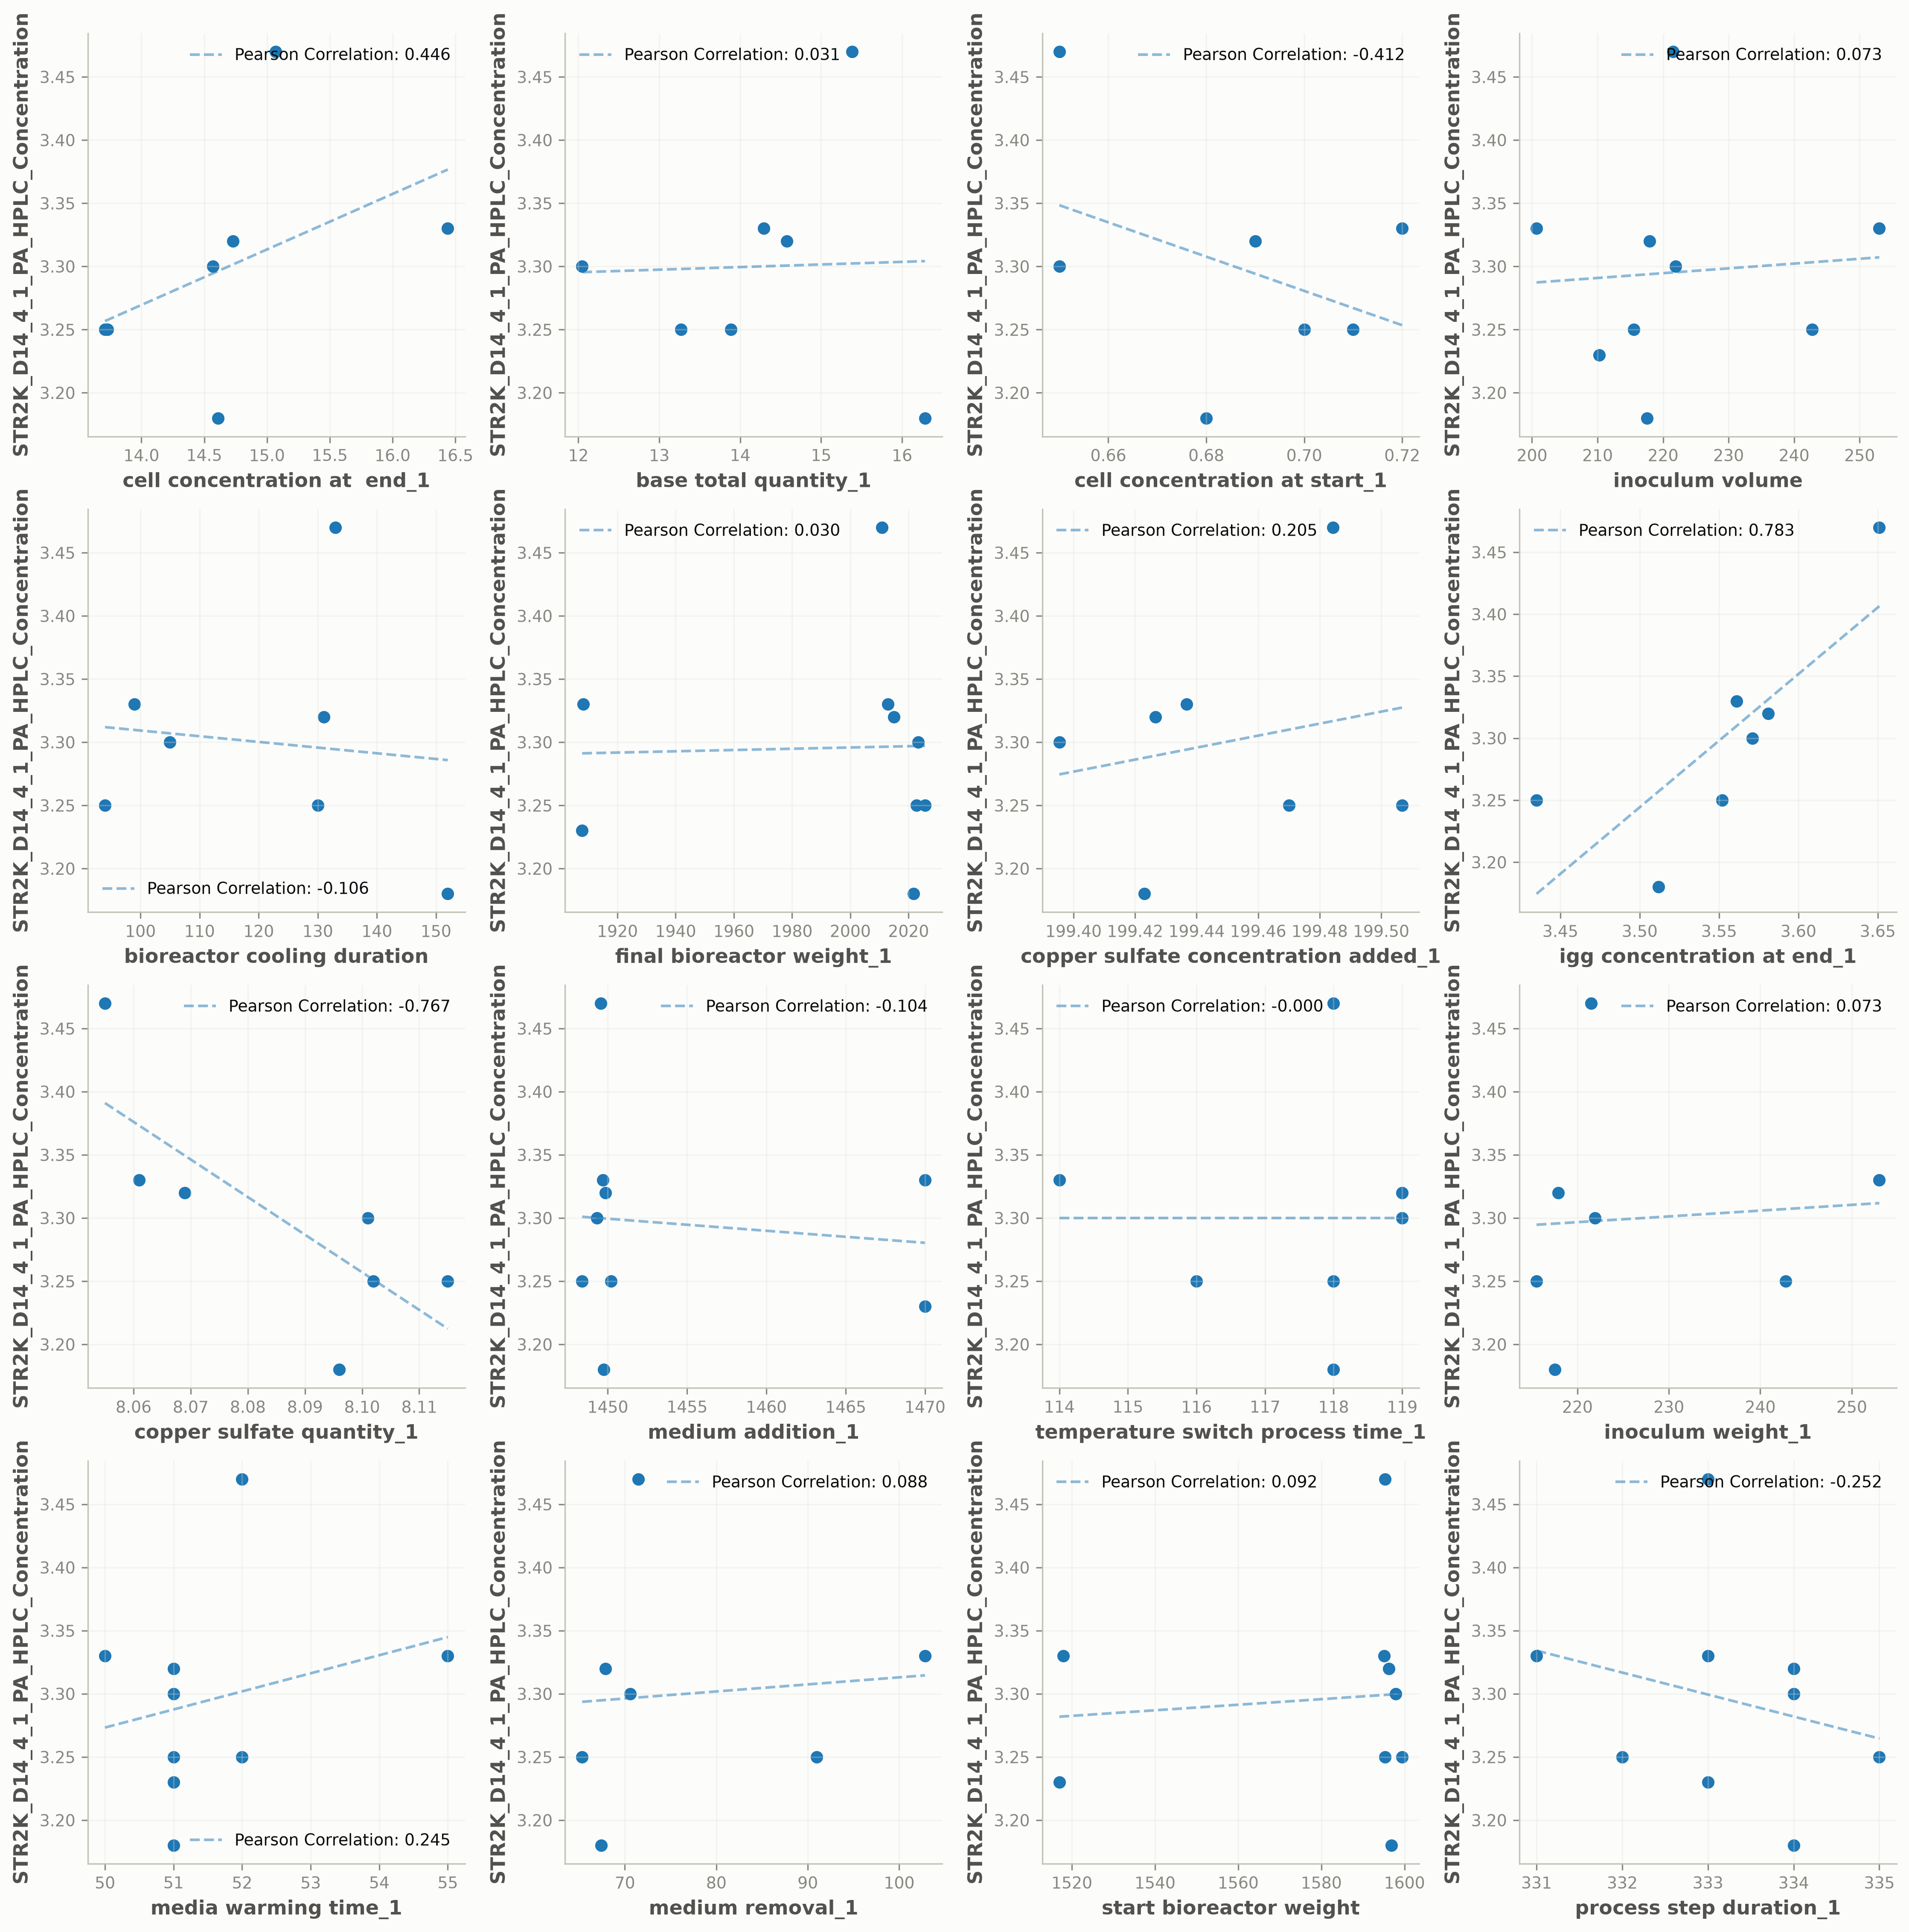

In [21]:
fig, axs = plt.subplots(4, 4, figsize = (15, 15), dpi=300)
X_cols = order

for idx in range(X_cols.shape[0]):
    row_idx = idx // 4
    col_idx = idx % 4
    ax = axs[row_idx][col_idx]

    tmp_x = df[df.columns[10]]
    tmp_y = df[X_cols[idx]]
    
    tmp_x = tmp_x[tmp_y.notna()]
    tmp_y = tmp_y[tmp_y.notna()]

    tmp_y = tmp_y[tmp_x.notna()]
    tmp_x = tmp_x[tmp_x.notna()]

    ax.scatter(tmp_y, tmp_x)
    m,b = np.polyfit(tmp_y.tolist(), tmp_x.tolist(), 1)
    corr = np.corrcoef(tmp_y.tolist(), tmp_x.tolist())[0, 1]
    min_val = tmp_y.min()
    max_val = tmp_y.max()
    ax.plot([min_val, max_val], [(min_val * m) + b, (max_val * m) + b], label = f"Pearson Correlation: {corr:.3f}", alpha = 0.5, linestyle = '--')
    ax.set_xlabel(X_cols[idx], fontsize=11, fontweight='bold')
    ax.set_ylabel(df.columns[10], fontsize=11, fontweight='bold')

    ax.grid(alpha = 0.3)
    ax.legend()

fig.tight_layout()